# Tutorial: Forecasting time series with echo state neural networks
*Author: Anastasia Bizyava*



In [11]:
import numpy as np
from scipy import sparse
from scipy import stats
from scipy.optimize import minimize
from tqdm.auto import tqdm
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import os


### Setting up the basics

In [12]:
class RC:
    """

    A class which implements a reservoir computing framework for data forecasting.

    A default initialization creates a classical reservoir computer with a tanh input nonlinearity
    and a linear output map.
    x(t+1) = (1 - alpha)*x + alpha*f(Ax(t) + Bu(t) + b)
    y(t) = Cx(t)
    Attributes:
    -----------
    Nx: integer dimension of reservoir
    Nu: integer dimension of input
    f: input activation function; tanh unless otherwise defined
    A: Nx by Nx array, reservoir weights
    B: Nx by Nu array, input weights
    b: Nx by 1 array, bias
    sigma: positive scalar, range of values for B matrix [-sigma, sigma]
    alpha: positive scalar, time scale of reservoir
    rho_sr: positive scalar, spectral radius of reservoir (used to construct A matrix)
    sigma_b: positive scalar, strength of bias in reservoir
    rho_A: positive scalar in (0,1], density of connections in A
    beta: Tikhonov regularization parameter
    Forecasting: True or False, internal flag
    Training: True or False, internal flag
    x: Nx by 1 array, current reservoir state
    t: integer, current time step
    xt: Nx by Nt array, state history during training
    xf: Nx by Nf array, state history during forecasting
    p_form: string, form of input weights ("linear" or "quadratic")
    add_LS_bias: True or False, flag for adding bias to readout vector in least squares problem (default is False)

    Methods:
    -----------
    StepForward(u_k)
        Evolve the reservoir one time step forward
    Train_Traj(U, lambd = 1e-6, quadratic = False)
        Train the output weights given the time history of inputs
    Forecast_Traj(K)
        Forecast the time history of outputs for K time steps forward given the time history of inputs up through current time step
    build_A()
        Construct the reservoir weight matrix A
    build_B()
        Construct the input weight matrix B
    get_p()
        Construct the observation vector p used in forecasting and training

    Authors: Anastasia Bizyaeva, Jan Williams
    e-mail: anabiz@uw.edu

    """

    def __init__(self, Nx=200, Nu=3, f=np.tanh, A = 0, B = 0, sigma = 0.084, alpha = 0.6, rho_sr=0.80, sigma_b=1.6, rho_A=0.02, beta=8.493901e-8,leak =1.0, p_form = "linear", add_LS_bias = False,):

        """

        Initialize a ReservoirComputer instance.

            Attributes:
            -----------
            Nx: integer dimension of reservoir
            Nu: integer dimension of input
            f: input activatiion function; tanh unless otherwise defined
            g: output activation function; g(x) = x unless otherwise defined
            A: Nx by Nx array, reservoir weights; randomly generated if not provided
            B: Nx by Nu array, input weights; randomly generated if not provided
            b: Nx by 1 array, bias added inside reservoir
            alpha: positive scalar, time step of reservoir
            rho_sr: positive scalar, spectral radius of absolute value of reservoir (used to construct A matrix)
            sigma: positive scalar, range of input weights [-sigma,sigma] used to generate B matrix
            sigma_b: positive scalar, scaling factor of bias (used to construct b vector)
            rho_A: scalar in [0,1] interval, probability of connection between reservoir nodes
            Forecasting: True or False, internal flag
            Training: True or False, internal flag
            x: Nx by 1 array, current reservoir state
            t: integer, current time step
            xt: Nx by Nt array, reservoir state history during training (initiated with initial condition)
            xf: Nx by Nf array, reservoir state history during forecasting (initiated empty)
            p_form: string, form of input weights ("linear" or "quadratic") - default "linear"
            add_LS_bias: True or False, flag for adding a random bias to readout vector in least squares (default is False)
            leak: leak rate of reservoir
        """

        self.Nx = Nx
        self.Nu = Nu
        self.f = f
        self.sigma = sigma
        self.alpha = alpha
        self.rho_sr = rho_sr
        self.sigma_b = sigma_b
        self.rho_A = rho_A
        self.beta = beta
        self.Forecasting = False
        self.Training = False
        self.p_form = p_form
        self.add_LS_bias = add_LS_bias
        self.x = np.zeros([self.Nx,1])
        self.leak=leak

        if isinstance(A,int):            # reservoir weights (initialized randomly when not user-supplied)
            # construct A matrix

            # generate sparse random matrix of size Nx by Nx with connection density rho_A
            A = self.build_A()

            # check if A is full rank, if not repeat until it is
            while_count = 0
            while np.linalg.matrix_rank(A) < Nx:
                A = self.build_A()
                while_count+=1
                if while_count > 10: # if A is not full rank after 10 tries, break and use A as is
                    print('Warning: A matrix is not full rank')
                    break
            self.A = A

        else:
            # A matrix is user-supplied

            # Check that A is a square matrix of size Nx by Nx
            if A.shape[0] != Nx or A.shape[1] != Nx:
                raise ValueError("A is not a square matrix of size Nx by Nx")
            else:
                self.A = A
        # input weights (initialized randomly when not user-supplied)
        # initialize B to be a random dense matrix of size Nx by Nu with uniformly distributed entries between -sigma and sigma
        if isinstance(B,int):

            B = self.build_B()
            self.B = B

        else:
            # Check that B is a square matrix of size Nx by Nu
            if B.shape[0] != Nx or B.shape[1] != Nu:
                raise ValueError("B is not a square matrix of size Nx by Nu")
            else:
                self.B = B

        self.t = 0                                          # initial time step
        #self.xt =np.array(self.x)                           # state history during training: add initial condition as first row of array
        #self.xf = np.empty((self.Nx,1),dtype=np.float64)    # state history during forecasting

        self.b = self.sigma_b * np.ones([self.Nx,1])        # construct bias vector

        self.train_counter = 0
        self.forecast_counter = 0


    def build_A(self):
        """
        Build a sparse random matrix A with connection density rho_A and spectral radius rho_sr
        Outputs:
        -----------
        A: Nx by Nx numpy array, sparse random matrix with density rho_A and spectral radius rho_sr
        """
        A = np.random.uniform(-1,1,size=self.Nx ** 2)
        del_indices = np.random.choice(self.Nx ** 2, size=int((1-self.rho_A)*self.Nx ** 2),replace=False)
        A[del_indices] = 0
        A = A.reshape(self.Nx, self.Nx)
        A = A*(self.rho_sr/np.max(np.abs(np.linalg.eigvals(A))))

        return A

    def build_B(self):
        """
        Build an input matrix B with entries chosen uniformly [-sigma, sigma]
        Outputs:
        -----------
        B: Nx by Nu numpy array, random input matrix mapping from dim(Nu) to dim(Nx)
        """
        B = np.random.uniform(-self.sigma, self.sigma, size=(self.Nx, self.Nu))
        return B


    def StepForward(self,u_k, i=None):
        """
        Advance the reservoir state one time step according to x(t+1) = (1-alpha)x(t) + alpha*tanh(Ax(t) + Bu(t) + b)
            Inputs:
            -----------
            u_k: Nu by 1 vector of inputs to the reservoir at the current time step
        """
        if u_k.shape[0] != self.Nu:
            raise ValueError("Input u_k is not a vector of length Nu")
        else:
            if u_k.ndim == 1:
                u_k = u_k.reshape(self.Nu,1) # convert u_k to a column vector

            self.x = (1 - self.alpha*self.leak)*self.x + self.alpha * self.f(self.A.dot(self.x) + self.B.dot(u_k) + self.b)         # update reservoir state taking one step forward

            if self.Training:
                self.xt[:, self.train_counter:1+self.train_counter] = self.x
                self.train_counter += 1
                #self.xt = np.concatenate((self.xt,self.x),axis=1)         # add current reservoir state to training history
            if self.Forecasting:
                self.xf[:, self.forecast_counter:1+self.forecast_counter] = self.x
                self.forecast_counter += 1
                #self.xf = np.concatenate((self.xf,self.x),axis=1)         # add current reservoir state to forecasting history
            self.t +=1

    def get_p(self,x_t):
        """

        Compute the parameter vector used in least squares problem in reservoir training and in forecasting

            Inputs:
            -----------
            x_t: either Nt by Nx array(reservoir state history) or Nx-element 1d array (reservoir state at a particular time step)
            Returns:
            -----------
            p: numpy array, parameter vector used in least squares problem in reservoir training and in forecasting

        """
        # check that input is a 2d array
        if x_t.ndim != 2:
            raise ValueError("Input must be a 2d array")


        Nt = x_t.shape[1] # number of time steps

        if self.p_form == "linear":
            p = x_t
        if self.p_form == "quadratic":
            p = np.concatenate((x_t,np.square(x_t)),axis = 0)
        if self.add_LS_bias:
            p = np.concatenate((np.ones([1,Nt]),p),axis = 0)

        return p



    def Train_Traj(self,U, spinup=500,verbose=False):
        """

        Train the output weights given the time history of inputs up through current time step

            Inputs:
            -----------
            U: 2darray with dimension Nu by Nt, time history of input for training
            lambd: regularization coefficient for pseudoinverse; prevents ill-conditioning of weights from overfitting

        """
        if U.shape[0] != self.Nu:
            raise ValueError("U is not a matrix of size Nu by number of training time steps")
        else:
            for i in range(spinup):
                self.StepForward(U[:,i])

            self.Training = True

            self.xt = np.zeros([self.Nx, len(U[0,spinup+1:])])
            if verbose == False:
                for i in range(spinup,U.shape[1] - 1):
                    self.StepForward(U[:,i])
                    if np.linalg.norm(self.x) > 1e10 or np.isnan(np.linalg.norm(self.x)):
                        print('Reservoir trajectory blew up after '+str(i)+' steps in training')
                        self.Training = False # turn off training flag
                        break
            if verbose == True:
                clear_output(wait=True)
                for i in tqdm(range(spinup,U.shape[1] - 1)):
                    self.StepForward(U[:,i])
                    if np.linalg.norm(self.x) > 1e10 or np.isnan(np.linalg.norm(self.x)):
                        print('Reservoir trajectory blew up after '+str(i)+' steps in training')
                        self.Training = False # turn off training flag
                        break
            x_mat = self.get_p(self.xt)
            u_mat = U[:, spinup+1:]

            # train output weights using regularized  least squares
            lhs = (x_mat.dot(x_mat.T) + self.beta * np.eye(self.Nx))
            rhs = x_mat.dot(u_mat.T)
            C_mat_T = np.linalg.lstsq(lhs, rhs, rcond=None)[0]
            self.C = C_mat_T.T

        self.Training = False

    def Forecast_Traj(self,K, spinup_data = None,verbose=False):
        """

        Assuming reservoir has been trained, forecast the trajectory forward in time

            Inputs:
            -----------
            K: integer, number of time steps for forward forecasting

        """

        ### forecast from the existing internal reservoir state x
        if spinup_data is not None:
            self.Training = False
            self.Forecasting = False
            self.x = np.zeros([self.Nx,1])
            for i in range(spinup_data.shape[1]):
                self.StepForward(spinup_data[:,i])

        self.Forecasting = True
        self.forecast_counter = 0
        self.xf = np.zeros([self.Nx, K])
        if verbose == False:
            for i in range(K):
                p = self.get_p(self.x)
                temp_u = self.C.dot(p)
                self.StepForward(temp_u)
                if np.linalg.norm(self.x) > 1e10 or np.isnan(np.linalg.norm(self.x)):
                        print('Forecasted trajectory blew up after '+str(i)+' steps')
                        self.Forecasting = False # turn off forecasting flag
                        break
        if verbose == True:
            for i in tqdm(range(K)):
                p = self.get_p(self.x)
                temp_u = self.C.dot(p)
                self.StepForward(temp_u)
                if np.linalg.norm(self.x) > 1e10 or np.isnan(np.linalg.norm(self.x)):
                        print('Forecasted trajectory blew up after '+str(i)+' steps')
                        self.Forecasting = False # turn off forecasting flag
                        break

        self.Forecasting = False


### TODO: Investigate computational speedups/parallelization for the optimization routine

In [13]:
# Lorenz system

def Lorenz(t, x, sigma=10, beta=8/3, rho=28):
    """
    Compute the time derivative of Lorenz system at time t.
    dx/dt = sigma * (y - x)
    dy/dt = x * (rho - z) - y
    dz/dt = x * y - beta * z

    Unless otherwide defined, parameters are sigma = 10, beta = 8/3, rho = 28.

        Inputs:
        ----------
        t : float
            Time.
        x : numpy array
            State vector [x, y, z].
        sigma : float, optional
            Parameter proportional to Prandtl number.
        beta : float, optional
            Parameter proportional to physical dimension of convection layer
        rho : float, optional
            Parameter proportional to Rayleigh number.

        Output
        ------
        dxdt : numpy array
            Derivative of the state vector.

    """
    return np.array([sigma * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - beta * x[2]])


### Exercise: Forecasting chaotic Lorenz dynamics

First we simulate the Lorenz system that we want to forecast

In [14]:
# time to simulate
T = 600

# initial condition
x0 = np.array([-0.1, 1, 1.05])

# simulation
dt_data = 0.01 # sampling time step
xt_lorenz = integrate.solve_ivp(Lorenz, [0, T], x0, method='RK45', t_eval=np.arange(0, T, dt_data),rtol=1e-12)
U = xt_lorenz.y # training signal

Next, we initialize and train the echo state network.

In [15]:
'''Nx: integer dimension of reservoir
    Nu: integer dimension of input
    f: input activatiion function; tanh unless otherwise defined
    A: Nx by Nx array, reservoir weights
    B: Nx by Nu array, input weights
    b: Nx by 1 array, bias
    sigma: positive scalar, range of values for B matrix [-sigma, sigma]
    alpha: positive scalar, leak rate of reservoir
    rho_sr: positive scalar, spectral radius of reservoir (used to construct A matrix)
    sigma_b: positive scalar, strength of bias in reservoir
    rho_A: positive scalar in (0,1], density of connections in A'''

# Play around with these parameters - how sensitive is the forecasting horizon to different parameter choices?

Nx=200; Nu=3; f=np.tanh; sigma=0.084; alpha=0.6; rho_sr=0.8; sigma_b=1.6; rho_A=0.1; beta=8.493901e-8;

rc = RC(Nx=Nx, Nu=3, f=f, A=0, B=0, sigma=sigma, alpha=alpha, rho_sr=rho_sr, sigma_b=sigma_b, rho_A=rho_A, beta=beta, p_form = "linear", add_LS_bias = False)

Finally, we train it!

In [16]:
train_len = 15000 # number of samples to use in training
sp = 500 # number of transient points to discard at the beginning
rc.Train_Traj(U[:,:train_len], spinup = sp)

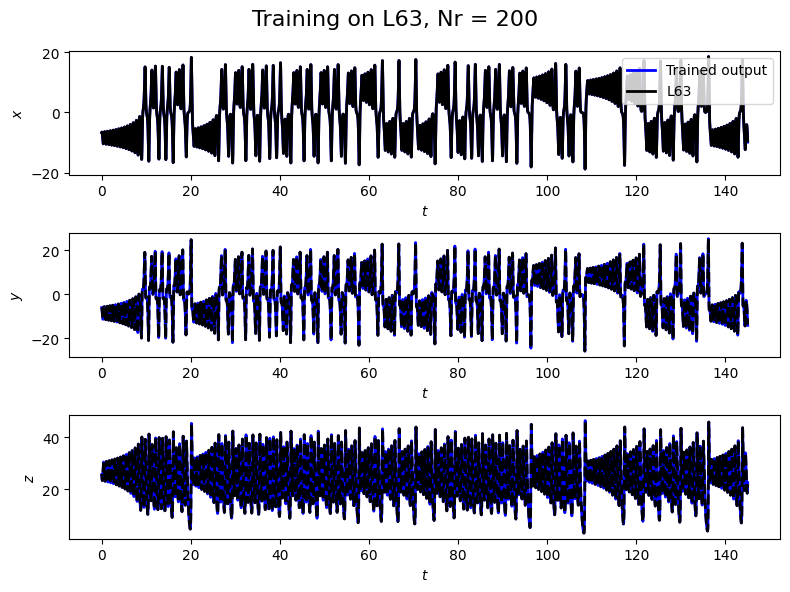

In [17]:
# visualize what's happening during training

y = rc.C.dot(rc.get_p(rc.xt))
t = np.linspace(0, (train_len-sp-1)*dt_data, train_len-sp-1)

#forecasted_traj = rc.C.dot(rc.get_p(rc.xf))
fig, ax = plt.subplots(3,1,figsize=(8,6))
fig.suptitle('Training on L63, Nr = '+str(Nx), fontsize=16)

# plot vertical gray line at train_t_spinup
ax[0].plot(t, y[0,:], 'b-', linewidth=2, label='Trained output')
ax[0].plot(t, U[0,sp:train_len-1], 'k-', linewidth=2, label='L63')
ax[0].set_xlabel('$ t$')
ax[0].set_ylabel('$x$')

ax[1].plot(t, y[1,:], 'b-', linewidth=2)
ax[1].plot(t, U[1,sp:train_len-1],'k--',linewidth=2)
ax[1].set_xlabel('$ t$')
ax[1].set_ylabel('$y$')

ax[2].plot(t, y[2,:], 'b-', linewidth=2)
ax[2].plot(t, U[2,sp:train_len-1], 'k--',linewidth=2)
ax[2].set_xlabel('$ t$')
ax[2].set_ylabel('$z$')
plt.tight_layout()
ax[0].legend(loc='upper right')
plt.show()

In [18]:
forecast_len = 2000 # number of time steps to forecast
rc.Forecast_Traj(forecast_len)

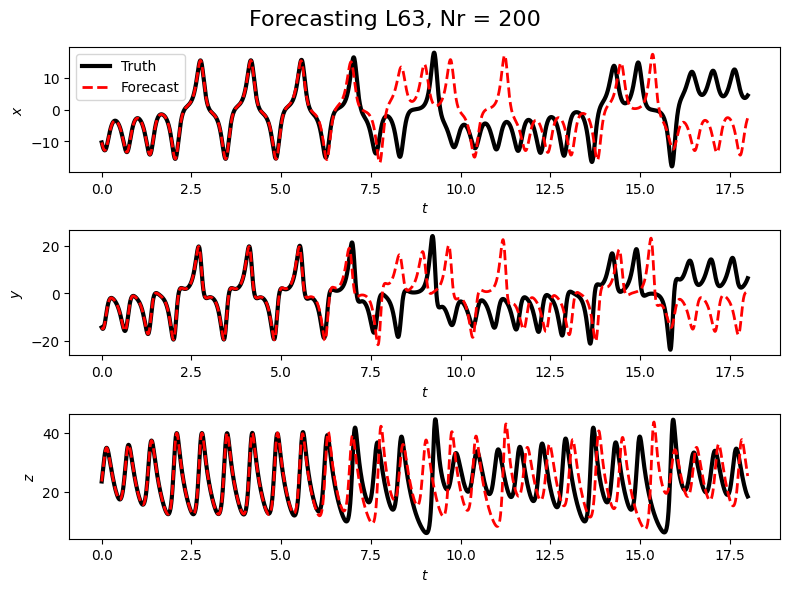

In [19]:
forecasted_traj = rc.C.dot(rc.get_p(rc.xf))
t = np.linspace(0, forecast_len*dt_data, forecast_len) * 0.9 ### characteristic Lyapunov timescale, 0.9 = lambda1 the largest Lyapunov exponent
fig, ax = plt.subplots(3,1,figsize=(8,6))
fig.suptitle('Forecasting L63, Nr = '+str(rc.Nx), fontsize=16)

ax[0].plot(t, U[0, train_len:train_len+forecast_len], 'k-', linewidth=3, label='Truth')
ax[0].plot(t, forecasted_traj[0,:],'r--', linewidth=2, label='Forecast')
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$x$')
#ax[0].set_ylim([-20,20])

ax[1].plot(t, U[1, train_len:train_len+forecast_len], 'k-', linewidth=3)
ax[1].plot(t, forecasted_traj[1,:],'r--',linewidth=2)
ax[1].set_xlabel('$ t$')
ax[1].set_ylabel('$y$')

ax[2].plot(t, U[2, train_len:train_len+forecast_len], 'k-', linewidth=3)
ax[2].plot(t, forecasted_traj[2,:],'r--',linewidth=2)

ax[2].set_xlabel('$t$')
ax[2].set_ylabel('$z$')
plt.tight_layout()
ax[0].legend()
plt.show()

A paper that explores systematically how much different hyperparameters matter in reservoir learning can be found here https://www.sciencedirect.com/science/article/pii/S0893608022002404

### Bonus Exercise : Partial observation


Modify the code from the previous exercise to only observe one of the three states of the Lorenz system. Are you able to forecast it? play around with hyperparameters.


How might we improve the architecture to do better with forecasting a partially observed system? For one strategy, see the preprint below.
https://arxiv.org/abs/2211.05992

In [20]:
path = "/run/user/1001/gvfs/smb-share:server=steinmetzsuper1.biostr.washington.edu,share=data/Subjects/ZYE_0069/2023-10-03/1"
dir_list = os.listdir(path)
print("Files and directories in '", path, "' :")
print("read data")

ortho_path = path+'/ortho/'

ortho_temp = np.load(path + '/ortho/svdTemporalComponents_ortho.npy')
ortho_spat  = np.load(path + '/ortho/svdSpatialComponents_ortho.npy')



cam_times = np.load(path + '/corr/svdTemporalComponents_corr.timestamps.npy')



print("ortho shape")

print(ortho_temp.shape)
ao = np.linalg.norm(ortho_temp[:,:],2,0)
print(ao.shape)

ortho_tempn = ortho_temp[:,:]/ao
print(ortho_tempn.shape)

Files and directories in ' /run/user/1001/gvfs/smb-share:server=steinmetzsuper1.biostr.washington.edu,share=data/Subjects/ZYE_0069/2023-10-03/1 ' :
read data
ortho shape
(500, 50641)
(50641,)
(500, 50641)


In [168]:
'''Nx: integer dimension of reservoir
    Nu: integer dimension of input
    f: input activatiion function; tanh unless otherwise defined
    A: Nx by Nx array, reservoir weights
    B: Nx by Nu array, input weights
    b: Nx by 1 array, bias
    sigma: positive scalar, range of values for B matrix [-sigma, sigma]
    alpha: positive scalar, leak rate of reservoir
    rho_sr: positive scalar, spectral radius of reservoir (used to construct A matrix)
    sigma_b: positive scalar, strength of bias in reservoir
    rho_A: positive scalar in (0,1], density of connections in A'''

# Play around with these parameters - how sensitive is the forecasting horizon to different parameter choices?

Nx=250; Nu=5; f=np.tanh; sigma=0.1; alpha=0.7; rho_sr=0.1; sigma_b=2; rho_A=0.98; beta=8.493901e-7;

rc = RC(Nx=Nx, Nu=Nu, f=f, A=0, B=0, sigma=sigma, alpha=alpha, rho_sr=rho_sr, sigma_b=sigma_b, rho_A=rho_A, beta=beta, p_form = "linear", add_LS_bias = False)

In [169]:
train_len = 20000 # number of samples to use in training
sp = 50 # number of transient points to discard at the beginning
rc.Train_Traj(ortho_tempn[:Nu,:train_len], spinup = sp)

In [170]:
forecast_len = 100 # number of time steps to forecast
rc.Forecast_Traj(forecast_len)

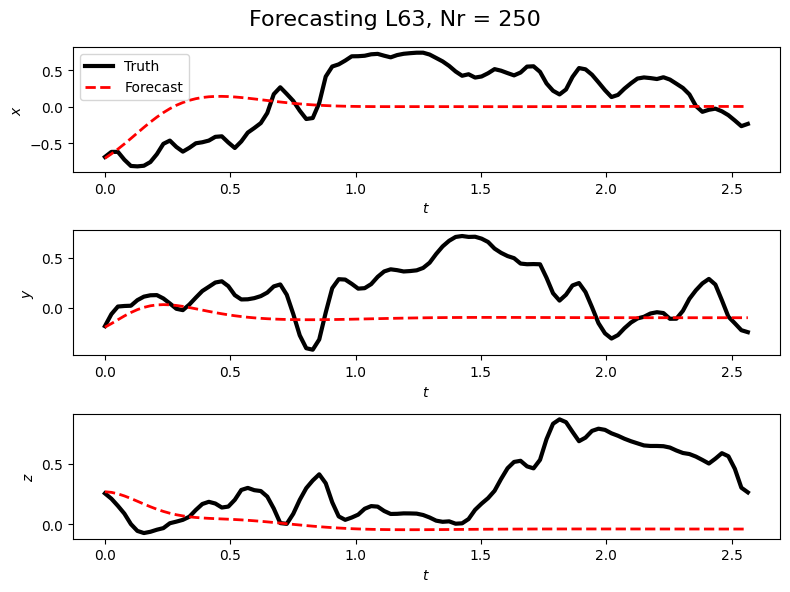

In [171]:

dt_data = 0.0285
forecasted_traj = rc.C.dot(rc.get_p(rc.xf))
t = np.linspace(0, forecast_len*dt_data, forecast_len) * 0.9 ### characteristic Lyapunov timescale, 0.9 = lambda1 the largest Lyapunov exponent
fig, ax = plt.subplots(3,1,figsize=(8,6))
fig.suptitle('Forecasting L63, Nr = '+str(rc.Nx), fontsize=16)

ax[0].plot(t, ortho_tempn[0, train_len:train_len+forecast_len], 'k-', linewidth=3, label='Truth')
ax[0].plot(t, forecasted_traj[0,:],'r--', linewidth=2, label='Forecast')
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$x$')
#ax[0].set_ylim([-20,20])

ax[1].plot(t, ortho_tempn[1, train_len:train_len+forecast_len], 'k-', linewidth=3)
ax[1].plot(t, forecasted_traj[1,:],'r--',linewidth=2)
ax[1].set_xlabel('$ t$')
ax[1].set_ylabel('$y$')

ax[2].plot(t, ortho_tempn[2, train_len:train_len+forecast_len], 'k-', linewidth=3)
ax[2].plot(t, forecasted_traj[2,:],'r--',linewidth=2)

ax[2].set_xlabel('$t$')
ax[2].set_ylabel('$z$')
plt.tight_layout()
ax[0].legend()
plt.show()